---
---
# EXPLORATORY DATA ANALYSIS

---
---

## ROADMAP: where we've been, and where we're going

In recent lectures we learned about **PPDAC**, a structured framework for data-driven problem solving:

<div style="text-align: center;">
<img src="https://raw.githubusercontent.com/ntstevens/DATSC101/58fc1f744c0caf95ae25e32836bb8625c59a40b7/images/PPDAC.svg" alt="PPDAC" width="800"/>
</div>

* **Problem:** a clear statement of the study's objectives, usually involving one or more questions.
* **Plan:** the procedures used to carry out the study including how we will collect the data.
* **Data:** the physical collection of the data, as described in the Plan.
* **Analysis:** the analysis of the data collected in light of the Problem and the Plan.
* **Conclusion:** The conclusions that are drawn from the Analysis about the Problem and their limitations.

In the coming lectures we begin to use this framework, stage by stage, with actual data and actual code. 

We begin with **exploratory data analysis** which is used to answer descriptive and exploratory questions by investigating datasets to summarize their main characteristics, uncover underlying relationships, and spot anomalies, primarily using statistical summaries and data visualization.


---
---

## About the Data: MLB Salaries

<div style="text-align: center;">
  <img src="https://img.mlbstatic.com/mlb-images/image/private/t_16x9/t_w2208/mlb/crbela7xbocusesq8f8v.jpg" alt="mlb_logo" width = 600/>
</div>

[Image Source](https://www.mlb.com/official-information)

Throughout this section we will illustrate ideas, principles, and tasks through the exploratory analysis of Major League Baseball (MLB) salaries.

The data we'll analyze is stored in the `mlb_2025_salaries.csv` file made available on both LEARN and [here on GitHub](https://github.com/ntstevens/DATSC101/blob/main/data/mlb_2025_salaries.csv). The data in its raw form comes from [spotrac.com](https://www.spotrac.com/mlb/rankings/player/_/year/2025/sort/cap_base), an online financial resource for professional sports.

The dataset is composed of salaries and other information for each of the 1512 players in the MLB during the 2025 season. For each player, the following information is recorded:

* `Player Name`: The player's name
* `Team Abbreviation`: The player's team, recorded as a 2 or 3-character abbreviation. A dictionary for the abbreviations is found [here](https://mlb10theshow.fandom.com/wiki/Team_Abbreviations).
* `Position`: The player's position(s), recorded as a 1 or 2-character abbreviations. A dictionary for the abbreviations is found [here](https://www.yourdictionary.com/articles/baseball-positions-abbreviations).
* `2025 Base Salary ($)`: The player's base salary for the 2025 season (in USD).


Let's load it in using the `pd.read_csv()` function we've used previously:

In [ ]:
import pandas as pd

mlb_salaries = pd.read_csv('https://raw.githubusercontent.com/ntstevens/DATSC101/refs/heads/main/data/mlb_2025_salaries.csv')
mlb_salaries

,Player Name,Team Abbreviation,Position,2025 Base Salary ($)
0,A.J. Puk,ARI,RP/CL,2950000
1,Adrian Del Castillo,ARI,C,760000
2,Alek Thomas,ARI,CF,793000
3,Andrew Hoffman,ARI,RP,760000
4,Andrew Saalfrank,ARI,RP,760000
...,...,...,...,...
1507,Sauryn Lao,WSH,RP,760000
1508,Shinnosuke Ogasawara,WSH,RP,1500000
1509,Trevor Williams,WSH,SP,7000000
1510,Trey Lipscomb,WSH,3B,760000


### ACTIVITY 🗣

**Before we analyze this data, let's give some thought to the Problem, Plan, and Data.**

* What type of data is this?
* What are some questions we _can_ answer with this data?
* What are some questions we _can't_ answer with this data?
* What is a *unit* in this dataset?
* What is the *target population*?
* What is the *response variable* and what are the *explanatory variables*?


---
---

## Data Frames and Other Data Structures

In Tutorial 2 we introduced **tabular data**, data that can be stored in a spreadsheet in row-column format. Recall, tabular data is structured such that

* Rows represent the objects we study. We call these **observations**.
* Columns represent characteristics of those objects. We call these **variables**.
* A **cell** contains the value of a particular variable for a particular observation.

When we load tabular data into Python using `pandas`, it is represented as a **data frame** object. In this section we will dig deeper into what a data frame object is, and along the way consider other _data structures_.

Formally, a data frame is a collection of **series** stuck together. What is a series then?

* A series is an object that contains one or more elements of any _data type_ in a single column.
* We can create a series in `pandas` using `pd.Series()`:


In [ ]:
import pandas as pd

courses = pd.Series(["MATH135", "MATH137", "CS125", "PSYCH101","MUSIC140"])
courses

0     MATH135
1     MATH137
2       CS125
3    PSYCH101
4    MUSIC140
dtype: object

As you can see above, this series has 5 elements and is composed of strings. But as noted above, a series can elements of _any_ data type. Here is another example in which the series is composed of numbers.

In [ ]:
grades = pd.Series([92, 81, 80, 91, 87])
grades

0    92
1    81
2    80
3    91
4    87
dtype: int64

Note that the argument passed into `pd.Series()` above is called a **list**, which is a data structure composed of lists of elements, or potentially different data types inside square  brackets `[]`. Below is a summary of different data types you may encounter in Python. 

|Data Type | Abbreviation | Description | Example |
| --- | --- | --- | --- |
|integer | `int` | positive/negative/zero whole numbers | `101` |
|floating point number | `float` | decimal number | `3.14159` |
|boolean | `bool` | true or false | `True` |
|string | `str` | text | `"DATSC101"` |
|none | `NoneType` | no value | `None` |

Acknowledgement: this table is reproduced from a similar table given in our textbook [Data Science: A First Introduction with Python](https://python.datasciencebook.ca/wrangling.html#tab-datatype-table).

Although a single series can contain elements of multiple data types simultaneously (e.g., `pd.Series(["DATSC", 101])` which combines a string and and integer is technically permissible), we generally avoid it. 

This is because a series is typicaly used to represent a column in a data frame, and a column in a data frame records measurements on a single variable, and that variable prescribes a particular data type.

In fact, we can construct a data frame using multiple series. Below, we construct a 2-column data frame using the series `courses` and `grades` defined above.

In [ ]:
df = pd.DataFrame({"Course": courses, "Grade": grades})
df

,Course,Grade
0,MATH135,92
1,MATH137,81
2,CS125,80
3,PSYCH101,91
4,MUSIC140,87


Note that the argument passed into `pd.DataFrame()` above is called a **dictionary**, which is a data structure composed of pairs of **keys** and **values** inside curly brackets `{}`. Each element starts with the `key` on the left, followed by a colon symbol `:`, and then the `value` on the right. A dictionary can have multiple key-value pairs, each separted by a comma, as we saw above.

Below is a summary of the various data structures we've encountered so far.

|Data Structure | Python Name | Description|
| --- | --- | --- |
|List | `list` | An ordered collection of elements of any data type. |
|Dictionary | `dict` | A labeled data structure where `keys` are paired with `values`. |
|Series | `Series` | An ordered and labelled collection of elements of any data type. | 
|Data frame | `DataFrame` | A labeled data structure with `Series` columns of potentially different types. |

Acknowledgement: this table is reproduced from a similar table given in our textbook [Data Science: A First Introduction with Python](https://python.datasciencebook.ca/wrangling.html#tab-datastruc-table).

While we work primarily with data frames, it's helpful to understand series and dictionaries because, as we've now seen, a data frame is composed of these. Next we look at working with a data frame, once we've read it in.

---
---

## Working with Data Frames

In this section we will overview how to:

* find helpful information about a data frame,
* subset the data frame by extracting specific rows and/or columns,
* modify rows and/or columns, and
* add rows and/or columns.

We illustrate all of this in the context of the MLB salary data.

### Learning about a data frame

Data frames have many important attributes that are helpful to know when understanding the data they contain. For instance, the number of rows and columns, the column names, and the data types stored in those columns.

We can access this information using built in **methods** associated with the `DataFrame` object itself. In particular, we will illustrate the use of the following:
* `df.shape`
* `df.columns`
* `df.rename`
* `df.info()`

Note that a _method_ is slightly different from a _function_. We've seen an used functions aleady. Recall their definition:

> *"A function is a reusable, self-contained block of code designed to perform a specific task."*

Previously, we passed an argument into a function, and that function performed some calculation on that input.

A method behaves similarly--it often performs some calculation--but its defined and applied explicitly with respect to some object. For our purposes, you can think of the difference simply in how the calculation is invoked.

For example, imagine some hypothetical calculation called `calculate()` we want to perform on an `object`. 

* The invocation of the *function* would be `calculate(object)`.
* The invocation of the *method* would be `object.calculate()`.

It turns out that when the `object` is a `DataFrame`, there are several helpful methods we can apply. The three above are just the tip of the iceburg. 


#### How many rows and columns does a data frame have?

Knowing the answer to this question tells you how many observations (rows) and variables (columns) are in the datset. We can use the `df.shape` method to determine this:

In [ ]:
mlb_salaries.shape

(1512, 4)

We can see from the output above that there are 1512 rows and 4 columns. This agrees with the description of the data provided above: we have 4 variables (name, team, position, salary) measured on each of 1512 baseball players.

#### What are the column names? And can I change them?

We've seen that the header row in a data frame provides columns names. In small data frames this information might be obtained immediately by opening and viewing a `.csv` file. But in many real-world applications, there may be dozens, hundreds, or even thousands of columns, in which case have a simple line of code to view and store these names can be helpful. We use the `df.columns` method to do this.

In [ ]:
mlb_salaries.columns

Index(['Player Name', 'Team Abbreviation', 'Position', '2025 Base Salary ($)'], dtype='object')

Some of these column names are a bit cumbersome, especially if we have to type them again and again in the code the performs our analyses. In a case like this, it can be useful to relabel the columns with shorter (but still informative) names. We use the `df.rename` method to do this.

In [ ]:
mlb_salaries.rename(columns={"Player Name": "Name", 
                             "Team Abbreviation": "Team",
                             "Position": "Position",
                             "2025 Base Salary ($)": "Salary"})

,Name,Team,Position,Salary
0,A.J. Puk,ARI,RP/CL,2950000
1,Adrian Del Castillo,ARI,C,760000
2,Alek Thomas,ARI,CF,793000
3,Andrew Hoffman,ARI,RP,760000
4,Andrew Saalfrank,ARI,RP,760000
...,...,...,...,...
1507,Sauryn Lao,WSH,RP,760000
1508,Shinnosuke Ogasawara,WSH,RP,1500000
1509,Trevor Williams,WSH,SP,7000000
1510,Trey Lipscomb,WSH,3B,760000


You can see above that we passed a dictionary into the `df.rename`, and in doing so we updated all of the column names except `Position`, which was already short and informative.

However, while the line of code above created a new data frame with updated column names, we didn't actually change the original `mlb_salaries` data frame. Observe:

In [ ]:
mlb_salaries.columns

Index(['Player Name', 'Team Abbreviation', 'Position', '2025 Base Salary ($)'], dtype='object')

If we want to update the data frame itself, we have to overwrite the old one with the new one as follows:

In [ ]:
mlb_salaries = mlb_salaries.rename(columns={"Player Name": "Name", 
                                            "Team Abbreviation": "Team",
                                            "Position": "Position",
                                            "2025 Base Salary ($)": "Salary"})
mlb_salaries.columns

Index(['Name', 'Team', 'Position', 'Salary'], dtype='object')

#### Is there an all-in-one method that gives me all this information?

The answer is yes, and it's the `df.info()` method. It tells you how many rows and columns the data frame contains, it tells you the column names, and it tells you the type of data contained in those columns.

In [ ]:
mlb_salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      1512 non-null   object
 1   Team      1512 non-null   object
 2   Position  1512 non-null   object
 3   Salary    1512 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 47.4+ KB


---
---

### Filtering Columns

In many data analyses we care about some columns more than others. In cases like these, we may choose to _filter_ our data frame to restrict attention to only the column(s) we're primariliy interested in. This is done with the square brackets `[]` operator. Within these square brackets, we need only specify the column(s) we wish to retain.

#### Filtering One Column

In the context of MLB salaries, we care most about the `Salary` column, so we could restrict attention to it alone.

In [ ]:
mlb_salaries["Salary"]

0       2950000
1        760000
2        793000
3        760000
4        760000
         ...   
1507     760000
1508    1500000
1509    7000000
1510     760000
1511     760400
Name: Salary, Length: 1512, dtype: int64

This returns a `Series` of the 1512 salaries only. Note that the general principle works as follows:

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/ntstevens/DATSC101/1d015e0ae312ec485e0f6d3e2e657a8933cbc8b7/images/column_filter.svg" alt="mlb_logo" height = "200"/>
</div>

#### Filtering Multiple Columns

In the context of MLB salaries, suppose we're most interested in how salaries change from one team to another, and we care less about positions. In this case, we could filter the columns such that `Position` is removed.

In [ ]:
mlb_salaries[["Name", "Team", "Salary"]]

,Name,Team,Salary
0,A.J. Puk,ARI,2950000
1,Adrian Del Castillo,ARI,760000
2,Alek Thomas,ARI,793000
3,Andrew Hoffman,ARI,760000
4,Andrew Saalfrank,ARI,760000
...,...,...,...
1507,Sauryn Lao,WSH,760000
1508,Shinnosuke Ogasawara,WSH,1500000
1509,Trevor Williams,WSH,7000000
1510,Trey Lipscomb,WSH,760000


This returns a `DataFrame` with 3 columns. It is the original `mlb_salaries` data frame, but with the `Position` column removed. Note that the general principle works as follows:
<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/ntstevens/DATSC101/1d015e0ae312ec485e0f6d3e2e657a8933cbc8b7/images/columns_filter.svg" alt="mlb_logo" height = "200"/>
</div>

In both cases above, we filtered columns by combined the square bracket operator `[]` with column names. But it's important to notice that the number of brackets used depended on how many columns were being filtered:

* when filtering one column, we use one set of brackets `[]` and they contain the relevant column name
* when filtering multiple column, we use two sets of brackets `[[]]` and they contain the relevant column names, each separate by commas

**Aside:**

* In the latter example we simple dropped a column from the original data frame. We can equivalently use the `df.drop` method to remove one or more columns.

In [ ]:
mlb_salaries.drop(columns = "Position")

,Name,Team,Salary
0,A.J. Puk,ARI,2950000
1,Adrian Del Castillo,ARI,760000
2,Alek Thomas,ARI,793000
3,Andrew Hoffman,ARI,760000
4,Andrew Saalfrank,ARI,760000
...,...,...,...
1507,Sauryn Lao,WSH,760000
1508,Shinnosuke Ogasawara,WSH,1500000
1509,Trevor Williams,WSH,7000000
1510,Trey Lipscomb,WSH,760000


---
---

### Filtering Rows

Filtering rows is as or more important in data analysis than filtering columns; filtering rows allows us to focus our analysis on particular subsets of the observations. It turns out we can also use the square bracket operator `[]` to filter a data frame's rows, but we use it differently than we did when filtering columns.

Because rows don't have names, we instead pass a _logical statement_ into `[]`. A logical statement is one that evaluates to `True` or `False` and arises through a logical comparison. The table below gives examples of logical comparisons as well as the corresponding Python syntax.

|Comparison | Operator | `True` example | `False` Example |
| --- | :-: | :-: | :-: |
|Less than | `<` | `2 < 3` | `2 < 2` |
|Greater than | `>` | `3 > 2` | `3 > 3` |
|Less than or equal | `<=` | `2 <= 2` | `3 <= 2` |
|Greater or equal | `>=` | `3 >= 3` | `2 >= 3` |
|Equal | `==` | `3 == 3` | `3 == 2` |
|Not equal | `!=` | `3 != 2` | `2 != 2` |

The goal is to establish a logical statement that specifies exactly which rows to include in the filtered data frame. Once such a statement is defined, we can filter the rows as follows:

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/ntstevens/DATSC101/1d015e0ae312ec485e0f6d3e2e657a8933cbc8b7/images/row_filter.svg" alt="mlb_logo" height = "200"/>
</div>

In the context of MLB salaries, suppose we're most interested in the Toronto Blue Jays in which case we want to restrict attention to players whose `Team` is `TOR`. The following statement is a logical comparison checking whether each player's `Team` is `TOR`.

In [ ]:
mlb_salaries["Team"] == "TOR"

0       False
1       False
2       False
3       False
4       False
        ...  
1507    False
1508    False
1509    False
1510    False
1511    False
Name: Team, Length: 1512, dtype: bool

The result is a `Series` of type `bool`. That is, a column of 1512 `True` and `False` values (one for each player). Although they're hidden in the suppressed output above, each of the elements corresponding to a Blue Jay is `True` and all other elements (corresponding to every play who is not a Blue Jay) are `False`.

With this logical statement defined, we're ready to filter `mlb_salaries`:

In [ ]:
mlb_salaries[mlb_salaries["Team"] == "TOR"]

,Name,Team,Position,Salary
1417,Adam Macko,TOR,SP,123900
1418,Addison Barger,TOR,SS,760000
1419,Alejandro Kirk,TOR,C,4600000
1420,Andres Gimenez,TOR,2B,10000000
1421,Angel Bastardo,TOR,P,760000
1422,Anthony Santander,TOR,LF,13500000
1423,Bo Bichette,TOR,SS,16500000
1424,Bowden Francis,TOR,SP,781500
1425,Braydon Fisher,TOR,RP,760000
1426,Brendon Little,TOR,RP,771800


While the command above created the desired data frame, the new data frame is not saved. To do so, we need to assign it to a variable:

In [ ]:
blue_jays = mlb_salaries[mlb_salaries["Team"] == "TOR"]

Note that because every player in this filtered data frame is a Blue Jay, the `Team` column is redundant. Let's remove it:

In [ ]:
blue_jays = blue_jays.drop(columns = "Team")
blue_jays

,Name,Position,Salary
1417,Adam Macko,SP,123900
1418,Addison Barger,SS,760000
1419,Alejandro Kirk,C,4600000
1420,Andres Gimenez,2B,10000000
1421,Angel Bastardo,P,760000
1422,Anthony Santander,LF,13500000
1423,Bo Bichette,SS,16500000
1424,Bowden Francis,SP,781500
1425,Braydon Fisher,RP,760000
1426,Brendon Little,RP,771800


Currently this data frame is sorted alphabetically by `Name`. However, it would be interesting to sort the data frame by `Salary` to easily identify 

* who are the highest and lowest paid Blue Jays, and 
* what are those salaries? 

It turns out we have a method `df.sort_values` that does this for us. By default, it sorts from smallest to largest (`ascending = True`) but in this case it's more interesting to sort from largest to smallest (`ascending = False`).

In [ ]:
blue_jays.sort_values(by = "Salary", ascending = False)

,Name,Position,Salary
1462,Vladimir Guerrero Jr.,1B,28500000
1443,Kevin Gausman,SP,23000000
1434,George Springer,CF,22500000
1427,Chris Bassitt,SP,21000000
1441,Jose Berrios,SP,18000000
1423,Bo Bichette,SS,16500000
1448,Max Scherzer,SP/SP2,15500000
1422,Anthony Santander,LF,13500000
1420,Andres Gimenez,2B,10000000
1457,Shane Bieber,SP/SP1,10000000


We find:
* the first basement Vladimir Guerrero Jr. has the largest base salary at \$28,500,000 and
* two starting pitchers, Jake Bloss and Adam Macko, have the lowest base salaries at \$123,900

Summing the values in the `Salary` column of the `blue_jays` data frame would give us the _team payroll_ (i.e., the total amount paid out in salaries). The method `sum()`, when applied to the appropriate column, can do exactly this:

In [ ]:
blue_jays["Salary"].sum()

258022350

So, we find that the Blue Jays paid \$258,022,350 in player salaries during the 2025 season.

How does this compare to their World Series nemesis, the LA Dodgers?

---

#### ACTIVITY 💻: Calculate the team payroll for the LA Dodgers in 2025.

---
---

### Filtering Columns _and_ Rows

We have seen that the square bracket operator is powerful in it's ability to filter both columns and rows. However, it can only do one of these at a time. If we instead want to filter by rows and columns _simultaneously_, we need a new operator. This is where the method `df.loc[]` comes in. The general principle works as follows:

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/ntstevens/DATSC101/1d015e0ae312ec485e0f6d3e2e657a8933cbc8b7/images/loc_example.svg" alt="mlb_logo" height = "200"/>
</div>

We can see that it combines:
* the logical statement used to filter rows, and 
* the list of column names to filter, and
* these are separated by a comma.

Previously we defined the `blue_jays` data frame by first filtering rows to include only those players whose `Team` was `TOR`, and then filtering columns to exclude `Team`. Using the `df.loc[]` method we can do these two steps all at once:

In [ ]:
mlb_salaries.loc[mlb_salaries["Team"] == "TOR", ["Name", "Position", "Salary"]]

,Name,Position,Salary
1417,Adam Macko,SP,123900
1418,Addison Barger,SS,760000
1419,Alejandro Kirk,C,4600000
1420,Andres Gimenez,2B,10000000
1421,Angel Bastardo,P,760000
1422,Anthony Santander,LF,13500000
1423,Bo Bichette,SS,16500000
1424,Bowden Francis,SP,781500
1425,Braydon Fisher,RP,760000
1426,Brendon Little,RP,771800


---
---

### Advanced Filtering with Conjunctions and Disjunctions

The logical statements considered so far have been composed of a _single_ statement. But we can define a logical statement by combining _multiple_ statements with:

* _conjunctions_ (i.e., **and**), represented in Python by `&`
    * `logical_statement1 & logical_statement2` evaluates to `True` if _both of_ `logical_statement1` and `logical_statement2` are `True`. Otherwise it evaluates to `False`.
* _disjunctions_ (i.e., **or**), represented in Python by `|`
    * `logical_statement1 & logical_statement2` evaluates to `True` if _one or both of_ `logical_statement1` and `logical_statement2` are `True`. Otherwise it evaluates to `False`.

In [ ]:
# AND Example
(2 > 3) & (2 < 5)

False

In [ ]:
# OR Example
(2 > 3) | (2 < 5)

True

Suppose we want to investigate the salaries of Blue Jays pitchers. To do so, we need to filter the `mlb_salaries` data frame to find the Blue Jays **and** the pitchers.

We already know how to find the Blue Jays. The logical statement `mlb_salaries["Team"] == "TOR"` does that for us. We'll return to that momentarily.

Now we need to figure out how to find pitchers. If you scroll through either the `mlb_salaries` or `blue_jays` data frames, you'll see this is complicated by the fact that many players play multiple positions. So, we're looking for players whose `Position` is one of `[P, SP, RP]`. There are many ways to do this, but one elegant solution is to notice that only pitchers have a `P` in their `Position` value. So, we could filter rows so that the `Position` string contains a `P`. Fortunately the `str.contains()` method does exactly this. Let's illustrate this on the `blue_jays` data frame.

In [ ]:
blue_jays["Position"].str.contains("P")

1417     True
1418    False
1419    False
1420    False
1421     True
1422    False
1423    False
1424     True
1425     True
1426     True
1427     True
1428    False
1429    False
1430     True
1431     True
1432     True
1433    False
1434    False
1435    False
1436     True
1437     True
1438     True
1439    False
1440    False
1441     True
1442     True
1443     True
1444     True
1445    False
1446     True
1447     True
1448     True
1449    False
1450    False
1451     True
1452     True
1453     True
1454     True
1455     True
1456     True
1457     True
1458     True
1459     True
1460    False
1461    False
1462    False
1463     True
1464     True
Name: Position, dtype: bool

This clearly did _something_; the result is boolean series. To see that this in fact worked as intended, let's add this column to the `blue_jays` data frame.

In [ ]:
is_pitcher = blue_jays["Position"].str.contains("P")
blue_jays["Is_A_Pitcher?"] = is_pitcher
blue_jays

,Name,Position,Salary,Is_A_Pitcher?
1417,Adam Macko,SP,123900,True
1418,Addison Barger,SS,760000,False
1419,Alejandro Kirk,C,4600000,False
1420,Andres Gimenez,2B,10000000,False
1421,Angel Bastardo,P,760000,True
1422,Anthony Santander,LF,13500000,False
1423,Bo Bichette,SS,16500000,False
1424,Bowden Francis,SP,781500,True
1425,Braydon Fisher,RP,760000,True
1426,Brendon Little,RP,771800,True


Success! We can see that every pitcher has a value of `True` in the `Is_A_Pitcher?` column, and every other play has a `False`. This provides assurance that `mlb_salaries["Position"].str.contains("P")` is in fact a logical statement that can be used to filter rows to retain only pitchers.

Let's put this altogether now:

In [ ]:
logical_statement1 = (mlb_salaries["Team"] == "TOR")
logical_statement2 = (mlb_salaries["Position"].str.contains("P"))
mlb_salaries[logical_statement1 & logical_statement2]

,Name,Team,Position,Salary
1417,Adam Macko,TOR,SP,123900
1421,Angel Bastardo,TOR,P,760000
1424,Bowden Francis,TOR,SP,781500
1425,Braydon Fisher,TOR,RP,760000
1426,Brendon Little,TOR,RP,771800
1427,Chris Bassitt,TOR,SP,21000000
1430,Dillon Tate,TOR,RP,1400000
1431,Easton Lucas,TOR,SP,800000
1432,Eric Lauer,TOR,RP,2200000
1436,Jacob Barnes,TOR,RP,1400000


---

#### ACTIVITY 💻: In 2025, how much more did the Blue Jays pay for pitchers than outfielders?

---
---

### Adding and Updating Columns

You may have missed it, but in the last section you saw how to _add_ a new column to a data frame. 

* Suppose you have values stored in a series called `new_data` and you want to add it the data frame `df` with the name `"My_New_Column"`. The command to do so is:

```
df["My_New_Column"] = new_data
```

You can analogously _update_ an existing column in a data frame. 

* Suppose the data frame `df` contains a column called `"Pizza"` and you want to replace its contents with the `new_data` series described above. The command to do so is:

```
df["Pizza"] = new_data
```

---
---

## Exploring Univariate Data

In a **univariate analysis** we analyze *one variable* with the goal of understanding it's *distribution*. That is, the kinds values it takes on. More simply, we're interested an answering the question *"what does this column look like?"*

As we will see, the strategies we employ for univariate analysis depends on the variable's type. Common examples of variable types and their approprotae analysis methods are provided in the table below.

| **Type** | **Summary Statistics** | **Data Visualizations** |
|---|---|:-:|
| **Categorical** (unordered labels) | frequency and proportion tables | bar chart|
| **Ordinal** (ordered labels) | frequency and proportion tables | line chart |
| **Numeric** (quantities) | measures of location and spread | histogram, boxplot, rug plot |

---
---

### Summarizing a Single Categorical Variable

A categorical variable holds **labels**, regardless of how they're recorded (e.g., answers to a survey question may be *tes* or *no*, but recorded in the data as `1` or `2`. You can't average a label. So a simple test of whether a numeric value in a dataset should be treated as numeric is to answer the question *"does it make sense to average this?"* 

The best summary of a categorical variable is to count **how many of each label there are**. In statistical terms, we call this a **frequency**. 

In the MLB salary data, the variables `Team` and `Position` are both categorical. Recall their definitions:

* `Team`: The player's team, recorded as a 2 or 3-character abbreviation. 
* `Position`: The player's position(s), recorded as a 1 or 2-character abbreviations. 

To illustrate the ideas of this section, we'll focus on the `Team` variable. 

The first thing to illustrate are the following methods associated with `pandas` data frames:

* `nunique()`: this tells you how many labels are associated with a categorical variable
* `unique()`: this lists the labels associated with a categorical variable






In [ ]:
mlb_salaries["Team"].nunique()

30

In [ ]:
mlb_salaries["Team"].unique()

array(['ARI', 'ATH', 'ATL', 'BAL', 'BOS', 'CHC', 'CHW', 'CIN', 'CLE',
       'COL', 'DET', 'HOU', 'KC', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN',
       'NYM', 'NYY', 'PHI', 'PIT', 'SD', 'SEA', 'SF', 'STL', 'TB', 'TEX',
       'TOR', 'WSH'], dtype=object)

We see there are 30 teams coded with the 3-character abbreviations listed above.

As we've seen before, `TOR` is one of the labels in the `Team` column. The number of times `TOR` appears in the `Team` column tells us how many players played for the Toronto Blue Jays in 2025. Likewise, the number of times `LAD` appears in the `Team` column tells us how many players played for the LA Dodgers in 2025.

Thus, counting the number of times each `Team` label occurs determines each team size. To automate this kind of counting, we can use the `value_counts()` method associated with `pandas` data frames:

* `value_counts()`: tabulates the frequency of each label of a categorical variable

In [ ]:
mlb_salaries["Team"].value_counts()

Team
ATL    59
BAL    58
LAA    57
HOU    56
LAD    56
ARI    55
CHW    55
NYM    55
BOS    54
DET    54
TB     53
MIA    51
COL    51
CLE    50
CIN    50
SEA    49
MIL    49
TEX    49
ATH    48
TOR    48
SF     48
WSH    47
SD     47
KC     46
PHI    46
PIT    46
CHC    45
NYY    45
MIN    44
STL    41
Name: count, dtype: int64

The output above tells shows us the Toronto Blue Jays had 48 players in 2025 and the LA Dodgers had 56.

**Aside:** How does this impact our earlier comparison of team salaries?

Let's look at the frequency of each `Position` across the league. 

In [ ]:
mlb_salaries["Position"].nunique()

47

In [ ]:
mlb_salaries["Position"].value_counts()

Position
RP          507
SP          245
C           108
SS          102
2B           75
3B           66
OF           58
CF           56
RF           49
1B           47
LF           40
DH           26
RP/CL        18
RP/SU8       16
SP/SP1       15
RP/SU7       14
SP/SP2       13
SP/SP3       11
SP/SP4        5
P             5
1B/OF         3
LF/C          3
2B/SS         3
1B/RF         2
SS/3B         2
SP/SP5        2
3B/SS         1
LF/RF         1
C/OF          1
1B/3B/DH      1
C/1B          1
1B/LF         1
1B/DH/2B      1
1B/2B         1
CF/SS         1
1B/3B         1
1B/DH         1
OF/1B         1
DH/SP         1
3B/LF         1
3B/SS/OF      1
2B/RF/DH      1
DH/LF         1
C/RF          1
2B/1B         1
CF/OF         1
DH/1B         1
Name: count, dtype: int64

There are 47 categories, many of them compounds. For example: `RP/CL` (relief pitcher who closes), `SP/SP1` (first starter in the rotation), etc. And several of these labels appear one or a small number of times.

Unfortunately, a categorical variable with 47 levels, most of them nearly empty, cannot be summarized usefully. This is a common problem in practice, and the typical fix is to **collapse categories**.

The compound labels all put the *primary* position first, so one option is to split the label at the `"/"` and keep only the
first piece, storing the *primary* position.

The `pandas` method `.str.split("/")` can be used for this purpose. This turns `"RP/CL"` into `["RP", "CL"]`. Extracting the first element with `.str[0]` retains the label of the primary position. Observe:

In [ ]:
mlb_salaries["PrimaryPos"] = mlb_salaries["Position"].str.split("/").str[0]
mlb_salaries.head(20)

,Name,Team,Position,Salary,PrimaryPos
0,A.J. Puk,ARI,RP/CL,2950000,RP
1,Adrian Del Castillo,ARI,C,760000,C
2,Alek Thomas,ARI,CF,793000,CF
3,Andrew Hoffman,ARI,RP,760000,RP
4,Andrew Saalfrank,ARI,RP,760000,RP
5,Aramis Garcia,ARI,C,760000,C
6,Austin Pope,ARI,RP,760000,RP
7,Blake Walston,ARI,RP,762700,RP
8,Blaze Alexander,ARI,SS,766300,SS
9,Brandon Pfaadt,ARI,SP,799400,SP


In [ ]:
mlb_salaries["PrimaryPos"].nunique()

13

There are now just 13. *This* we can summarize usefully.

---

#### ACTIVITY 💻: Tabulate the frequencies for the players' primary positions.


**Important Remark:**

> Collapsing threw away real information &mdash; we can no longer tell closers from other relievers. And this was a *choice* we made. We justify it by arguing the question ("how is the league distributed across positions?") does not need the detail. But every cleaning step like this is a choice. It's important to record them as part of our analysis.

---

While tabulating frequencies is useful, calculating **relative frequencies**, also called **proportions** can be more informative.

* A proportion for a given label divides the count by the total number of units, quantifying the *share of the whole* for that label: $$\text{proportion of label } k \;=\; \frac{\text{count of label } k}{n}$$ where $n$ is the total number of units in the dataset. 

* Proportions lie between 0 and 1 and always sum to 1.

* It turns out that the `value_count()` method can *also* perform this calculation, we just need to pass in an extra argument:

In [47]:
mlb_salaries["PrimaryPos"].value_counts(normalize = True)

PrimaryPos
RP    0.367063
SP    0.192460
C     0.073413
SS    0.068783
2B    0.052910
3B    0.045635
OF    0.039021
CF    0.038360
1B    0.038360
RF    0.032407
LF    0.029101
DH    0.019180
P     0.003307
Name: proportion, dtype: float64

When we multiply proportions by 100, we obtain **percentages**:

In [48]:
mlb_salaries["PrimaryPos"].value_counts(normalize = True)*100

PrimaryPos
RP    36.706349
SP    19.246032
C      7.341270
SS     6.878307
2B     5.291005
3B     4.563492
OF     3.902116
CF     3.835979
1B     3.835979
RF     3.240741
LF     2.910053
DH     1.917989
P      0.330688
Name: proportion, dtype: float64


---
---

### Visualizing a Single Categorical Variable

**Data visualization** is the graphical representation of information and data using visual elements like charts, graphs, and maps. Later in the course, we'll spend more time carefully studying data visualization tools and principles, but here we introduce the subject with some basic visualizations that support exploratory data analysis. 

Just as we've imported libraries to help with other data analysis tasks, we'll similarly import a library to provide the functions we need to construct data visualizations. There are many such libraries, but we'll primarily use `plotly` in this course; `plotly.express` to be specific. 

Let's import it below.

In [49]:
import plotly.express as px

The suite of data visualizations available to us via `plotly` can be explored in it's documentation [here](https://plotly.com/python/plotly-express/). For now, we'll focus on **bar charts**, the most common way to visualize categorical data. 

* A bar chart is a frequency table drawn to scale: one bar per label, with bar height proportional to the corresponding count. 

* It doesn't provide any more or less information than tabulated frequencies, but the eye compares bar heights much faster than it compares numbers in a column.

* With `plotly.express`, we can use the `px.bar()` function for this purpose.
    * `px.bar()` accepts either a `Series` or `DataFrame` as input
    * in the case of a `DataFrame`, additional arguments are needed to specify which column is to be plotted 

* Let's start by visualizaing the `PrimaryPos` variable with a minimalist call to `px.bar()` and then iteratively update the plot to

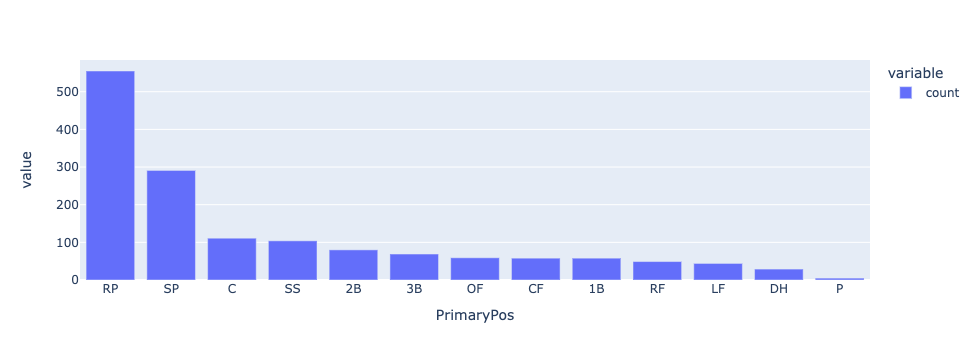

In [112]:
px.bar(mlb_salaries["PrimaryPos"].value_counts())

While this is *technically* a bar chart, we can improve its appearance and hence its ability to clearly communicate information. We do so by using and modifying the following arguments:
* `labels`: use a dictionary to redefine the axis labels.
* `title`: add a title to the plot.
* `color_discrete_sequence`: change the colour of the bars; [click here for available colours](https://plotly.com/python/css-colors/).
* `width` and `height`: change the width and height of the plot.
* `orientation`: controls whether the bars are oriented vertically (`"v"`) or horizontally (`"h"`).
* `text` and `textposition`: add the counts to the plot.
* `showlegend`: include (`True`) or exclude (`False`) the legend.

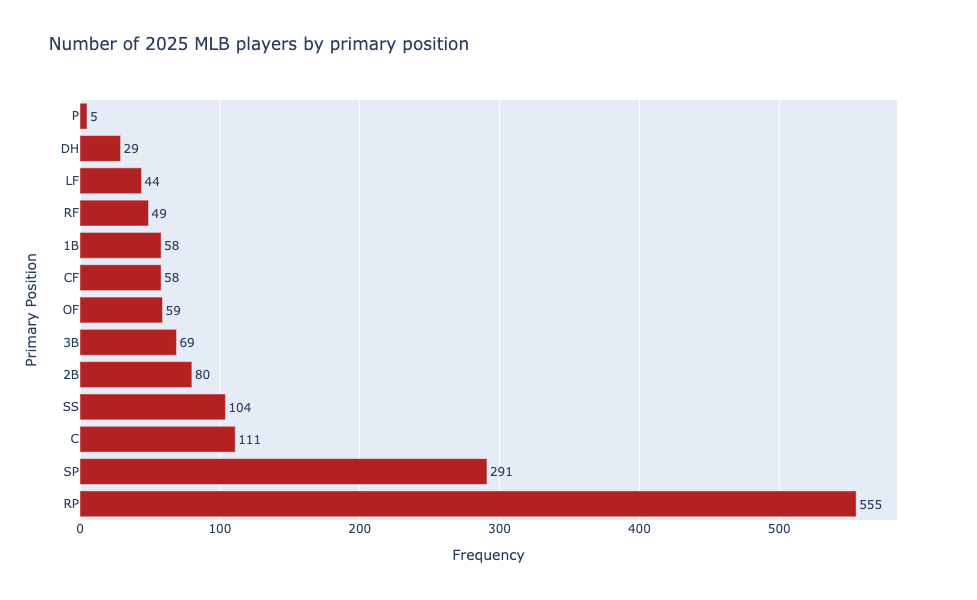

In [123]:
position_counts = mlb_salaries["PrimaryPos"].value_counts()

fig = px.bar(position_counts,
             labels={"PrimaryPos": "Primary Position", "value": "Frequency"},
             title="Number of 2025 MLB players by primary position",
             color_discrete_sequence=["firebrick"],
             width=900, height=600,
             orientation="h",
             text=position_counts)

fig.update_traces(textposition="outside", showlegend=False)
fig.show()

---

#### ACTIVITY 💻: Construct a bar chart of the 2025 MLB team sizes.

---
---

### Summarizing a Single Numeric Variable

---
---

### Visualizing a Single Numeric Variable

---
---

## Exploring Bivariate Data


---
---

## Summary of `DataFrame` Methods

We have so far learned several useful methods that may be applied to `DataFrame` objects which we summarize here. Suppose `df` is a data frame.

|Method | Description |
| --- | --- |
|`df.shape` | Returns the number of rows and columns in `df` | 
|`df.column` | Returns the names of the columns in `df` | 
|`df.rename` | Allows you to rename the columns in `df`| 
|`df.drop` | Allows you to remove one or more columns in `df`| 
|`df.info()` | Provides a summary of `df`| 
|`df.sort_values()` | Sorts the rows of `df` by one or more columns| 
|`df.head()` | Displays the top rows of `df`| 
|`df.tail()` | Displays the bottom rows of `df`| 

We also saw some helpful methods that could be applied directly to columns of `df`.

|Method | Description |
| --- | --- |
|`df["col_name"].sum()` | Sums the values contained in the numeric variable column `"col_name"`| 
|`df["col_name"].nunique()` | Count the number of unique labels in categorical variable column `"col_name"`| 
|`df["col_name"].unique()` | List the unique labels in categorical variable column `"col_name"` | 
|`df["col_name"].value_counts()` | Tabulate frequencies for the categorical variable column `"col_name"` | 
|`df["col_name"].str.contains()` | Checks whether the values in `"col_name"` contain the given string |
|`df["col_name"].str.split()` | Decomposes the strings in `"col_name"` at the given string | 

We will continue to expand these lists as we progress through the course.

---
---